# BÁO CÁO PHÂN TÍCH DỮ LIỆU CHUYẾN BAY DELTA AIR LINES
## Cải thiện tỷ lệ đúng giờ (On-time Performance)

---

**Thực hiện:** Nguyễn Minh Quân
**Phần phụ trách:** Phân tích Mô tả (Descriptive) và Phân tích Chẩn đoán (Diagnostic)
**Nguồn dữ liệu:** Kaggle *usdot/flight-delays* (2015), lọc riêng các chuyến bay của Delta Air Lines
**Phạm vi:** Toàn bộ chuyến bay nội địa Hoa Kỳ của Delta Air Lines trong năm 2015

---

### Mục lục

1. Giới thiệu và câu hỏi nghiên cứu
2. Dữ liệu và phạm vi phân tích (Analytical Population)
3. Phân tích Mô tả — 3 biểu đồ
4. Phân tích Chẩn đoán — 3 biểu đồ
5. Tổng hợp phát hiện chính (Key Findings)
6. Tóm tắt điều hành (Executive Summary)

## 1. Giới thiệu và câu hỏi nghiên cứu

### Bối cảnh

Delta Air Lines đang muốn cải thiện chỉ số đúng giờ (on-time performance) sau khi ghi nhận nhiều phản ánh từ khách hàng. Ban điều hành cần biết **chuyến bay, tuyến bay hoặc thời điểm nào có nguy cơ trễ cao** để chủ động điều chỉnh lịch bay và bố trí máy bay dự phòng trước mùa cao điểm.

### Câu hỏi nghiên cứu

> Các yếu tố về thời gian, sân bay khởi hành, tuyến bay và nguyên nhân vận hành ảnh hưởng như thế nào đến tình trạng trễ chuyến của Delta Air Lines, và Delta nên ưu tiên cải thiện ở đâu để nâng cao tỷ lệ đúng giờ trước mùa cao điểm?

### Cách tiếp cận

Câu hỏi trên được trả lời qua 4 lớp phân tích theo trình tự: **Mô tả** (chuyện gì đang xảy ra) → **Chẩn đoán** (vì sao xảy ra) → Dự đoán (chuyến nào có nguy cơ trễ) → Chỉ định (nên làm gì). Notebook này trình bày hai lớp đầu tiên.

Trong phần **Mô tả**, phân tích đi theo mạch: **Tổng quan → Sân bay nào? → Tuyến nào?**
Trong phần **Chẩn đoán**, phân tích đi theo mạch: **Nguyên nhân gì? → Khi nào? → Nghiêm trọng thế nào?**

Mỗi biểu đồ trong notebook đều có phần **📌 Nhận xét** ngay bên dưới, tổng kết ý nghĩa và số liệu chính rút ra được từ biểu đồ đó.

## 2. Dữ liệu và phạm vi phân tích (Analytical Population)

### 2.1. Nạp thư viện và cấu hình

In [17]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE_DIR = os.getcwd()
FLIGHTS_PATH = os.path.join(BASE_DIR, "flights_DL.csv")  # da loc rieng Delta Air Lines (DL)
AIRLINES_PATH = os.path.join(BASE_DIR, "airlines.csv")

sns.set_style("whitegrid")

# Nguong toi thieu de 1 tuyen duoc xet la "high-risk route", tranh truong
# hop tuyen chi bay vai chuyen nhung ty le tre 100% khong co y nghia thong ke.
MIN_FLIGHTS = 500

# Nguong toi thieu de 1 san bay khoi hanh duoc xem la san bay co san luong
# khai thac lon cua Delta (khong dung tu "hub" vi day khong phai dinh nghia
# hub chinh thuc theo mang bay hub-and-spoke, chi la nguong loc thong ke).
AIRPORT_MIN_FLIGHTS = 1000
TOP_N_AIRPORTS = 15

### 2.2. Nạp dữ liệu

Dữ liệu sử dụng gồm `flights_DL.csv` (đã được lọc riêng các chuyến của Delta Air Lines) và `airlines.csv` (bảng tra tên đầy đủ của hãng). Chỉ đọc các cột thật sự cần thiết và chỉ định kiểu dữ liệu tối ưu (category, int8, float32) để giảm dung lượng bộ nhớ khi xử lý file lớn.

In [18]:
usecols = [
    "MONTH", "DAY_OF_WEEK", "AIRLINE",
    "ORIGIN_AIRPORT_CLEAN", "DEST_AIRPORT_CLEAN",
    "SCHEDULED_DEPARTURE", "DISTANCE", "DIVERTED", "CANCELLED",
    "ARRIVAL_DELAY", "IS_DELAYED",
    "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY",
]

dtype_map = {
    "MONTH": "int8", "DAY_OF_WEEK": "int8", "AIRLINE": "category",
    "ORIGIN_AIRPORT_CLEAN": "category", "DEST_AIRPORT_CLEAN": "category",
    "SCHEDULED_DEPARTURE": "float32", "DISTANCE": "int32",
    "DIVERTED": "int8", "CANCELLED": "int8",
    "ARRIVAL_DELAY": "float32", "IS_DELAYED": "float32",
    "AIR_SYSTEM_DELAY": "float32", "SECURITY_DELAY": "float32",
    "AIRLINE_DELAY": "float32", "LATE_AIRCRAFT_DELAY": "float32",
    "WEATHER_DELAY": "float32",
}

print("[1] Doc du lieu tu flights_DL.csv...")
df = pd.read_csv(FLIGHTS_PATH, usecols=usecols, dtype=dtype_map)
print(f"    {df.shape[0]:,} dong, {df.shape[1]} cot.")

airlines = pd.read_csv(AIRLINES_PATH).rename(columns={"AIRLINE": "AIRLINE_NAME"})
df = df.merge(airlines, left_on="AIRLINE", right_on="IATA_CODE", how="left")
df.head()

[1] Doc du lieu tu flights_DL.csv...
    875,881 dong, 16 cot.


,MONTH,DAY_OF_WEEK,AIRLINE,SCHEDULED_DEPARTURE,DISTANCE,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ORIGIN_AIRPORT_CLEAN,DEST_AIRPORT_CLEAN,IS_DELAYED,IATA_CODE,AIRLINE_NAME
0,1,4,DL,25.0,1589,8.0,0,0,0.0,0.0,0.0,0.0,0.0,SFO,MSP,0.0,DL,Delta Air Lines Inc.
1,1,4,DL,30.0,1747,-15.0,0,0,0.0,0.0,0.0,0.0,0.0,LAS,ATL,0.0,DL,Delta Air Lines Inc.
2,1,4,DL,30.0,1199,-30.0,0,0,0.0,0.0,0.0,0.0,0.0,DEN,ATL,0.0,DL,Delta Air Lines Inc.
3,1,4,DL,35.0,1535,-4.0,0,0,0.0,0.0,0.0,0.0,0.0,LAX,MSP,0.0,DL,Delta Air Lines Inc.
4,1,4,DL,40.0,1590,-22.0,0,0,0.0,0.0,0.0,0.0,0.0,SLC,ATL,0.0,DL,Delta Air Lines Inc.


### 2.3. Định nghĩa biến mục tiêu `IS_DELAYED`

`IS_DELAYED` được tính trực tiếp từ `ARRIVAL_DELAY` trong bước làm sạch dữ liệu:
- **= 1** nếu `ARRIVAL_DELAY ≥ 15` phút (chuẩn của Bộ Giao thông Hoa Kỳ — US DOT)
- **= 0** nếu `ARRIVAL_DELAY < 15` phút
- **= không xác định** nếu không có `ARRIVAL_DELAY` (chủ yếu là chuyến bị hủy)

Kiểm chứng lại logic này trước khi phân tích, bằng cách đối chiếu `IS_DELAYED` với điều kiện `ARRIVAL_DELAY ≥ 15` được tính độc lập:

In [19]:
print("[1b] Doi chieu IS_DELAYED voi ARRIVAL_DELAY >= 15:")
pd.crosstab(df["IS_DELAYED"], df["ARRIVAL_DELAY"] >= 15)

[1b] Doi chieu IS_DELAYED voi ARRIVAL_DELAY >= 15:


ARRIVAL_DELAY,False,True
IS_DELAYED,,
0.0,752252,0
1.0,0,118023


**📌 Nhận xét:** bảng đối chiếu chỉ có giá trị khác 0 nằm trên đường chéo (0.0 ↔ False, 1.0 ↔ True) — xác nhận `IS_DELAYED` được tính đúng và nhất quán 100% với định nghĩa ≥15 phút, không có trường hợp ngoại lệ nào.

### 2.4. Xác định Analytical Population

Toàn bộ phân tích trong notebook chỉ xét các chuyến bay:
- **Không bị chuyển hướng** (`DIVERTED = 0`) — để đảm bảo `ARRIVAL_DELAY` phản ánh đúng thời gian đến sân bay đích ban đầu
- **Không bị hủy** (`CANCELLED = 0`)
- **Có giá trị `ARRIVAL_DELAY`**

Ba điều kiện được lọc tường minh (thay vì chỉ dựa vào `IS_DELAYED` tự động bỏ qua giá trị rỗng) để dễ kiểm chứng và đối chiếu số liệu.

In [20]:
n_before = df.shape[0]
n_diverted = int((df["DIVERTED"] == 1).sum())
n_cancelled = int((df["CANCELLED"] == 1).sum())
df = df[
    (df["DIVERTED"] == 0) &
    (df["CANCELLED"] == 0) &
    (df["ARRIVAL_DELAY"].notna())
].copy()
print(f"[1c] Loai {n_diverted:,} chuyen bi chuyen huong va {n_cancelled:,} chuyen "
      f"bi huy khoi {n_before:,} dong; con lai {df.shape[0]:,} dong.")

overall_rate = df["IS_DELAYED"].mean() * 100
n_eligible = int(df["IS_DELAYED"].notna().sum())
n_delayed = int(df["IS_DELAYED"].sum())
print(f"[2] Trong {n_eligible:,} chuyen du dieu kien, {n_delayed:,} chuyen tre "
      f">= 15 phut, tuong duong {overall_rate:.1f}%.")

[1c] Loai 1,782 chuyen bi chuyen huong va 3,824 chuyen bi huy khoi 875,881 dong; con lai 870,275 dong.
[2] Trong 870,275 chuyen du dieu kien, 118,023 chuyen tre >= 15 phut, tuong duong 13.6%.


**📌 Nhận xét:** trong 875.881 chuyến ban đầu, sau khi loại 1.782 chuyến chuyển hướng và 3.824 chuyến bị hủy, còn lại **870.275 chuyến đủ điều kiện phân tích**. Trong số này, **118.023 chuyến bị trễ từ 15 phút trở lên**, tương đương **tỷ lệ trễ chung 13,6%** — tức trung bình cứ khoảng 7-8 chuyến của Delta thì có 1 chuyến trễ. Đây là con số nền (baseline) dùng để so sánh xuyên suốt các phần phân tích tiếp theo.

## 3. Phân tích Mô tả (Descriptive Analysis)

*Mạch phân tích: Tổng quan → Sân bay nào? → Tuyến nào?*

### 3.1. Biểu đồ 1 — Tỷ lệ đúng giờ theo tháng

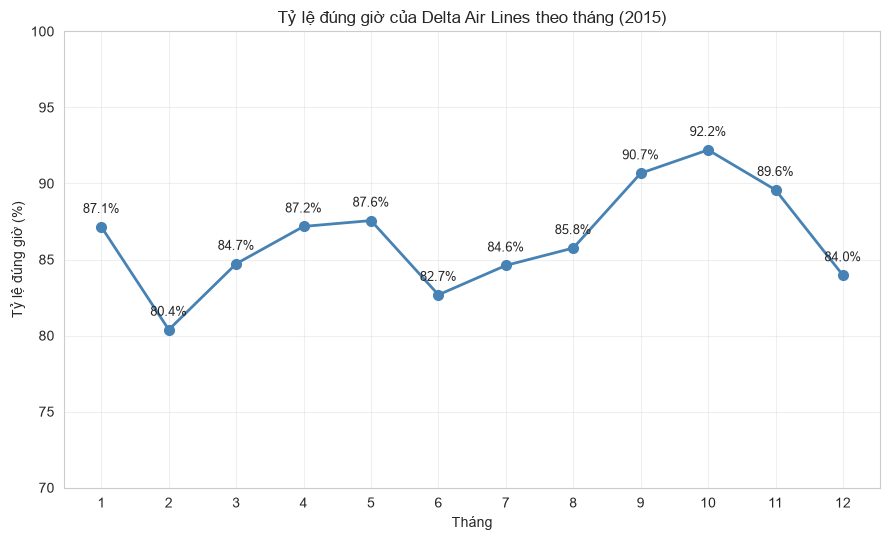

In [21]:
monthly = df.groupby("MONTH")["IS_DELAYED"].mean().reset_index()
monthly["ON_TIME_RATE"] = (1 - monthly["IS_DELAYED"]) * 100

plt.figure(figsize=(9, 5.5))
plt.plot(monthly["MONTH"], monthly["ON_TIME_RATE"], marker="o", color="steelblue",
          linewidth=2, markersize=7)
for x, y in zip(monthly["MONTH"], monthly["ON_TIME_RATE"]):
    plt.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 10),
                 ha="center", fontsize=9)
plt.title("Tỷ lệ đúng giờ của Delta Air Lines theo tháng (2015)")
plt.xlabel("Tháng")
plt.ylabel("Tỷ lệ đúng giờ (%)")
plt.xticks(range(1, 13))
plt.ylim(70, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "chart1_ontime_theo_thang.png"), dpi=150)
plt.show()

**📌 Nhận xét:** tỷ lệ đúng giờ dao động rõ rệt theo mùa, **thấp nhất vào tháng 2 (80,4%)** và **cao nhất vào tháng 10 (92,2%)**, chênh lệch tới **11,8 điểm phần trăm** giữa hai thời điểm. Tỷ lệ đúng giờ có xu hướng phục hồi dần từ tháng 6 (82,7%) và đạt đỉnh vào mùa thu (tháng 9-10), trước khi giảm nhẹ trở lại vào cuối năm (tháng 12 chỉ 84,0%). Mẫu hình này phù hợp với đặc điểm mùa cao điểm du lịch hè và các dịp lễ cuối năm gây áp lực lớn lên lịch bay và hạ tầng sân bay.

### 3.2. Biểu đồ 2 — Tỷ lệ trễ theo sân bay khởi hành

Đổi từ "theo hãng" sang "theo sân bay khởi hành" vì dữ liệu giờ chỉ còn 1 hãng (Delta), so sánh giữa các hãng không còn ý nghĩa. Không dùng từ "hub" vì đây chỉ là ngưỡng lọc thống kê, không phải định nghĩa hub chính thức theo mạng bay.

[4c] 157 san bay khoi hanh tong cong, 101 san bay dat nguong >= 1000 chuyen (san bay co san luong khai thac lon).


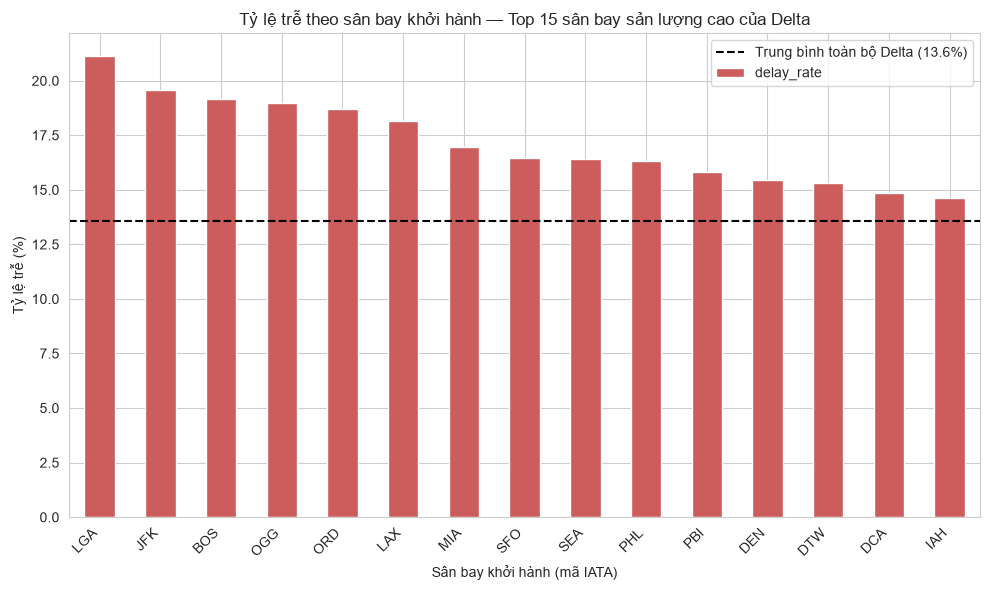

In [22]:
airport_summary = df.dropna(subset=["IS_DELAYED"]).groupby("ORIGIN_AIRPORT_CLEAN", observed=True).agg(
    total_flights=("IS_DELAYED", "size"),
    delay_rate=("IS_DELAYED", "mean"),
)
airport_summary["delay_rate"] *= 100
airport_eligible = airport_summary[airport_summary["total_flights"] >= AIRPORT_MIN_FLIGHTS]
print(f"[4c] {len(airport_summary)} san bay khoi hanh tong cong, {len(airport_eligible)} san bay dat "
      f"nguong >= {AIRPORT_MIN_FLIGHTS} chuyen (san bay co san luong khai thac lon).")

airport_rate = airport_eligible["delay_rate"].sort_values(ascending=False).head(TOP_N_AIRPORTS)

plt.figure(figsize=(10, 6))
airport_rate.plot(kind="bar", color="indianred")
plt.axhline(overall_rate, color="black", linestyle="--",
            label=f"Trung bình toàn bộ Delta ({overall_rate:.1f}%)")
plt.title(f"Tỷ lệ trễ theo sân bay khởi hành — Top {len(airport_rate)} sân bay sản lượng cao của Delta")
plt.xlabel("Sân bay khởi hành (mã IATA)")
plt.ylabel("Tỷ lệ trễ (%)")
plt.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "chart2_tre_theo_san_bay.png"), dpi=150)
plt.show()

**📌 Nhận xét:** trong 157 sân bay Delta khai thác, có 101 sân bay đạt ngưỡng tối thiểu 1.000 chuyến/năm để được xét vào nhóm sản lượng cao. **LGA (LaGuardia, New York)** có tỷ lệ trễ cao nhất: **21,1%**, cao hơn trung bình toàn Delta **7,6 điểm phần trăm** (tính trên số liệu chưa làm tròn). Đáng chú ý, 4 vị trí dẫn đầu (LGA, JFK, BOS, ORD) đều là các sân bay khu vực Đông Bắc và các thành phố lớn có mật độ không lưu cao — phản ánh áp lực từ hạ tầng không lưu khu vực này hơn là vấn đề riêng của Delta. Ngược lại, các sân bay ở cuối danh sách (DCA, IAH, MCO) có tỷ lệ trễ thấp hơn hẳn, dưới hoặc quanh mức trung bình toàn hãng.

### 3.3. Biểu đồ 3 — Route Risk: khối lượng khai thác so với tỷ lệ trễ

[4a] Loai 659 chuyen co ma san bay khong hop le (0.08% tong so) khoi phan tich tuyen bay.
[4b] 970 tuyen tong cong, 462 tuyen dat nguong >= 500 chuyen.


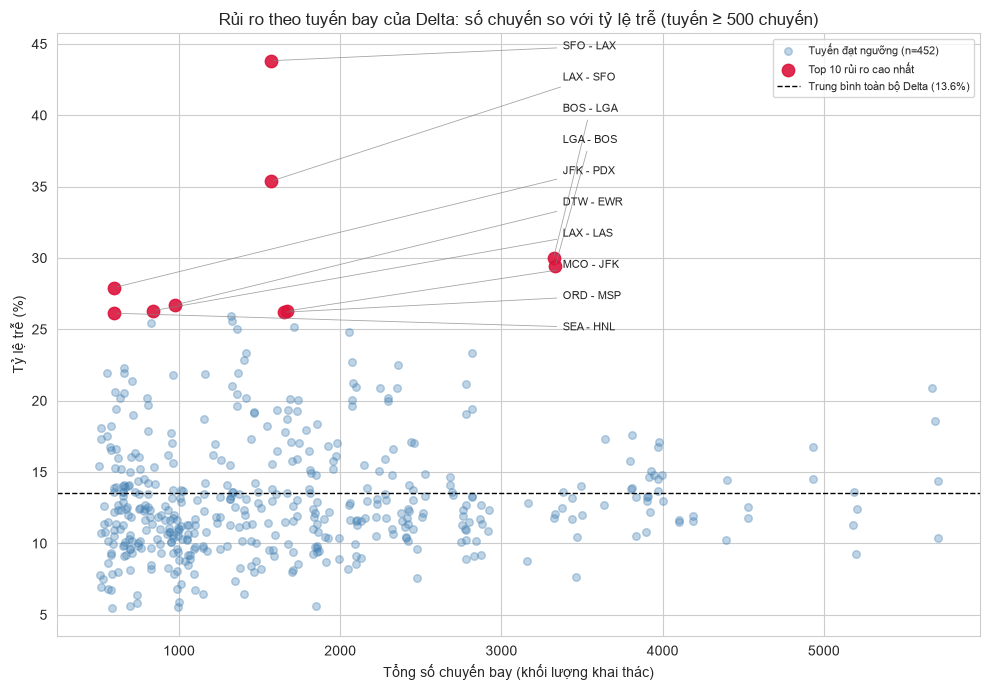

,total_flights,delayed_flights,delay_rate
ROUTE,,,
SFO - LAX,1570,688.0,43.821655
LAX - SFO,1569,555.0,35.372849
BOS - LGA,3323,997.0,30.003008
LGA - BOS,3333,980.0,29.402941
JFK - PDX,598,167.0,27.926422
DTW - EWR,977,261.0,26.714432
LAX - LAS,840,221.0,26.309523
MCO - JFK,1670,439.0,26.287424
ORD - MSP,1649,432.0,26.197697


In [23]:
df["ROUTE"] = df["ORIGIN_AIRPORT_CLEAN"].astype(str) + " - " + df["DEST_AIRPORT_CLEAN"].astype(str)

# Loai cac chuyen co ma san bay khong hop le (nhan "UNKNOWN" tu buoc lam sach)
# khoi phan tich tuyen bay, vi day khong phai 1 tuyen thuc te ma la tap hop
# nhieu ma san bay la bi gom chung, gay outlier khi ve bieu do.
n_before_route = df.shape[0]
df_route = df[
    (df["ORIGIN_AIRPORT_CLEAN"] != "UNKNOWN") & (df["DEST_AIRPORT_CLEAN"] != "UNKNOWN")
]
n_unknown = n_before_route - df_route.shape[0]
print(f"[4a] Loai {n_unknown:,} chuyen co ma san bay khong hop le "
      f"({n_unknown/n_before_route*100:.2f}% tong so) khoi phan tich tuyen bay.")

route_summary = df_route.dropna(subset=["IS_DELAYED"]).groupby("ROUTE").agg(
    total_flights=("IS_DELAYED", "size"),
    delayed_flights=("IS_DELAYED", "sum"),
    delay_rate=("IS_DELAYED", "mean"),
)
route_summary["delay_rate"] *= 100
route_summary_eligible = route_summary[route_summary["total_flights"] >= MIN_FLIGHTS].copy()
print(f"[4b] {len(route_summary)} tuyen tong cong, {len(route_summary_eligible)} tuyen dat "
      f"nguong >= {MIN_FLIGHTS} chuyen.")

top_routes_risk = route_summary_eligible.sort_values("delay_rate", ascending=False).head(10)
route_delay = top_routes_risk["delay_rate"]
route_summary_eligible["IS_TOP10"] = route_summary_eligible.index.isin(top_routes_risk.index)

normal_pts = route_summary_eligible[~route_summary_eligible["IS_TOP10"]]
top_pts = route_summary_eligible[route_summary_eligible["IS_TOP10"]]

plt.figure(figsize=(10, 7))
plt.scatter(normal_pts["total_flights"], normal_pts["delay_rate"],
            s=30, alpha=0.35, color="steelblue", label=f"Tuyến đạt ngưỡng (n={len(normal_pts)})")
plt.scatter(top_pts["total_flights"], top_pts["delay_rate"],
            s=80, alpha=0.9, color="crimson", label="Top 10 rủi ro cao nhất")

top_sorted = top_pts.sort_values("delay_rate", ascending=False)
label_x = route_summary_eligible["total_flights"].quantile(0.90)
y_positions = np.linspace(top_sorted["delay_rate"].max() + 1, top_sorted["delay_rate"].min() - 1, len(top_sorted))
for (route_name, row), y_label in zip(top_sorted.iterrows(), y_positions):
    plt.annotate(
        route_name,
        xy=(row["total_flights"], row["delay_rate"]),
        xytext=(label_x, y_label),
        fontsize=8,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.6, alpha=0.7),
        va="center",
    )
plt.axhline(overall_rate, color="black", linestyle="--", linewidth=1,
            label=f"Trung bình toàn bộ Delta ({overall_rate:.1f}%)")
plt.title(f"Rủi ro theo tuyến bay của Delta: số chuyến so với tỷ lệ trễ (tuyến ≥ {MIN_FLIGHTS} chuyến)")
plt.xlabel("Tổng số chuyến bay (khối lượng khai thác)")
plt.ylabel("Tỷ lệ trễ (%)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "chart3_route_risk_scatter.png"), dpi=150)
plt.show()

top_routes_risk

**Kiểm chứng nội bộ:** `total_flights` phải bằng đúng `delayed + ontime`, và `delay_rate` tính lại từ `delayed_flights/total_flights` phải khớp tuyệt đối.

In [24]:
route_summary["ontime_flights"] = route_summary["total_flights"] - route_summary["delayed_flights"]
assert (route_summary["total_flights"] ==
        route_summary["delayed_flights"] + route_summary["ontime_flights"]).all()
route_summary["check_rate"] = route_summary["delayed_flights"] / route_summary["total_flights"] * 100
max_diff = (route_summary["delay_rate"] - route_summary["check_rate"]).abs().max()
print(f"[5b] Kiem chung route: sai lech delay_rate lon nhat = {max_diff:.10f}")

[5b] Kiem chung route: sai lech delay_rate lon nhat = 0.0000050863


**📌 Nhận xét:** sau khi loại 659 quan sát có mã sân bay không hợp lệ (0,08% — tỷ lệ rất thấp), từ 970 tuyến thật có **462 tuyến đạt ngưỡng tối thiểu 500 chuyến**. Tuyến rủi ro cao nhất là **SFO–LAX** (San Francisco – Los Angeles): **43,8% trên 1.570 chuyến** — cao vượt trội so với phần còn lại. Đặc biệt, **chiều ngược lại LAX–SFO cũng lọt vào vị trí thứ 2** (35,4% trên 1.569 chuyến), cho thấy **cả hai chiều của cùng một cặp thành phố đều có rủi ro cao** — đây là tín hiệu rõ ràng nhất trong toàn bộ phân tích tuyến bay. Đồ thị scatter cũng cho thấy: các tuyến rủi ro cao nhất không nhất thiết là tuyến có khối lượng khai thác lớn nhất (trục hoành), nghĩa là "tuyến đông khách" và "tuyến rủi ro cao" là hai khái niệm khác nhau. Nguyên nhân cụ thể của hiện tượng SFO↔LAX cần được kiểm tra thêm theo thời tiết, lịch khai thác và các yếu tố vận hành — dữ liệu hiện có chưa đủ để kết luận nguyên nhân.

### Tổng kết Phân tích Mô tả

Ba biểu đồ trên cho thấy nguy cơ trễ chuyến của Delta **không phân bố đều** mà tập trung theo 3 chiều: **thời gian** (tháng 2 tệ nhất, tháng 10 tốt nhất), **không gian sân bay** (khu vực Đông Bắc rủi ro cao hơn), và **tuyến bay cụ thể** (cặp SFO↔LAX nổi bật bất thường ở cả hai chiều). Đây là cơ sở để đi sâu vào phần Chẩn đoán nhằm tìm hiểu **vì sao** các mẫu hình này xảy ra.

## 4. Phân tích Chẩn đoán (Diagnostic Analysis)

*Mạch phân tích: Nguyên nhân gì? → Khi nào? → Nghiêm trọng thế nào?*

### 4.1. Biểu đồ 4 — Tỷ trọng nguyên nhân gây trễ

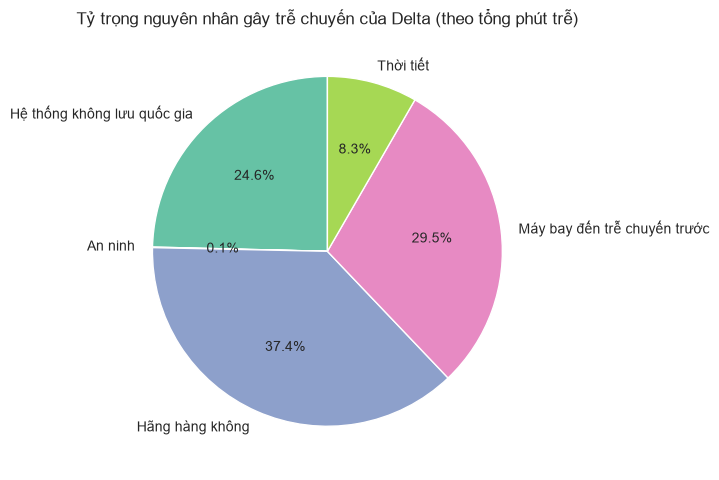

In [25]:
reason_cols = ["AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"]
reason_label = {
    "AIR_SYSTEM_DELAY": "Hệ thống không lưu quốc gia",
    "SECURITY_DELAY": "An ninh",
    "AIRLINE_DELAY": "Hãng hàng không",
    "LATE_AIRCRAFT_DELAY": "Máy bay đến trễ chuyến trước",
    "WEATHER_DELAY": "Thời tiết",
}
reason_totals = df.loc[df["IS_DELAYED"] == 1, reason_cols].sum()
reason_pct = reason_totals / reason_totals.sum() * 100
reason_pct.index = [reason_label[c] for c in reason_pct.index]

plt.figure(figsize=(7, 7))
plt.pie(reason_pct, labels=reason_pct.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("Set2"))
plt.title("Tỷ trọng nguyên nhân gây trễ chuyến của Delta (theo tổng phút trễ)")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "chart4_nguyennhan_tre.png"), dpi=150)
plt.show()

**📌 Nhận xét:** đối với riêng Delta, nhóm nguyên nhân liên quan đến hãng hàng không (`AIRLINE_DELAY`) chiếm tỷ trọng lớn nhất: **37,4% tổng phút trễ**, tiếp theo là trễ dây chuyền do máy bay đến trễ chuyến trước (`LATE_AIRCRAFT_DELAY`, 29,5%) và hệ thống không lưu quốc gia (`AIR_SYSTEM_DELAY`, 24,6%). Thời tiết chỉ chiếm 8,3% và an ninh gần như không đáng kể (0,1%). Đây là điểm khác biệt đáng chú ý so với bức tranh chung của toàn ngành hàng không (nơi trễ dây chuyền thường là nguyên nhân lớn nhất) — với Delta, nguyên nhân được ghi nhận cho hãng bay lại nổi bật hơn. Dữ liệu không nêu rõ thành phần cụ thể của `AIRLINE_DELAY` (ví dụ bảo trì, nhân sự...), nên không thể suy diễn thêm ngoài phạm vi được dataset ghi nhận.

### 4.2. Biểu đồ 5 — Tỷ lệ trễ theo giờ khởi hành và ngày trong tuần

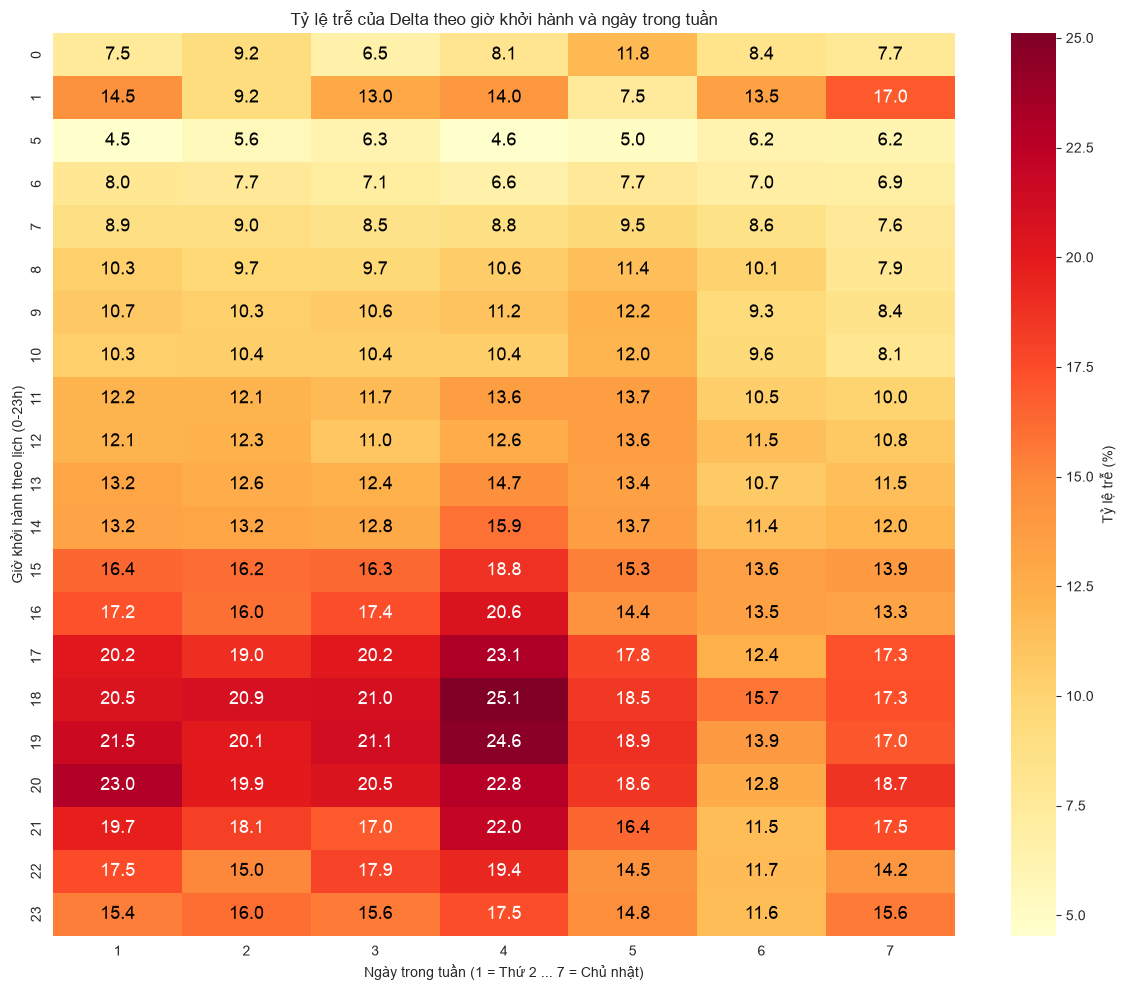

[7a] So o co duoi 50 chuyen quan sat trong ma tran gio x ngay: 0.


In [26]:
def extract_hour(x):
    try:
        return int(x) // 100
    except (ValueError, TypeError):
        return np.nan

df["SCHED_HOUR"] = df["SCHEDULED_DEPARTURE"].apply(extract_hour)
pivot = df.pivot_table(index="SCHED_HOUR", columns="DAY_OF_WEEK", values="IS_DELAYED", aggfunc="mean") * 100
count_pivot = df.pivot_table(index="SCHED_HOUR", columns="DAY_OF_WEEK", values="IS_DELAYED", aggfunc="count")

plt.figure(figsize=(12, 10))
ax = sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={"label": "Tỷ lệ trễ (%)"}, annot=False)
vmin, vmax = pivot.values.min(), pivot.values.max()
threshold = vmin + (vmax - vmin) * 0.6
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        value = pivot.values[i, j]
        text_color = "white" if value >= threshold else "black"
        ax.text(j + 0.5, i + 0.5, f"{value:.1f}", ha="center", va="center",
                 color=text_color, fontsize=13)
plt.title("Tỷ lệ trễ của Delta theo giờ khởi hành và ngày trong tuần")
plt.xlabel("Ngày trong tuần (1 = Thứ 2 ... 7 = Chủ nhật)")
plt.ylabel("Giờ khởi hành theo lịch (0-23h)")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "chart5_heatmap_gio_ngay.png"), dpi=150)
plt.show()

low_sample_cells = int((count_pivot < 50).sum().sum())
print(f"[7a] So o co duoi 50 chuyen quan sat trong ma tran gio x ngay: {low_sample_cells}.")
count_pivot.to_csv(os.path.join(BASE_DIR, "heatmap_hour_dow_count.csv"))

**Tỷ lệ trễ gộp theo giờ (`hour_summary`)** — dùng tổng số chuyến trễ chia tổng số chuyến đủ điều kiện tại từng giờ, **khác với việc lấy trung bình đơn giản của 7 tỷ lệ theo ngày** (cách tính không theo trọng số số chuyến thực tế từng ngày, dễ sai lệch vì các ngày có lưu lượng bay khác nhau, đặc biệt cuối tuần).

In [27]:
hour_summary = (
    df.dropna(subset=["IS_DELAYED"])
    .groupby("SCHED_HOUR", observed=True)
    .agg(
        total_flights=("IS_DELAYED", "size"),
        delayed_flights=("IS_DELAYED", "sum"),
        delay_rate=("IS_DELAYED", "mean"),
    )
)
hour_summary["delay_rate"] *= 100
hour_summary.to_csv(os.path.join(BASE_DIR, "hour_delay_summary.csv"))
hour_summary

,total_flights,delayed_flights,delay_rate
SCHED_HOUR,,,
0,3289,282.0,8.574035
1,439,55.0,12.528473
5,11987,650.0,5.422541
6,57821,4206.0,7.274174
7,61814,5388.0,8.716473
8,62271,6210.0,9.972540
9,54298,5666.0,10.435007
10,49735,5088.0,10.230220
11,56948,6837.0,12.005690


Để kiểm chứng xu hướng tăng theo giờ thay vì chỉ suy diễn từ hình dạng heatmap, tính thêm trung bình phút `LATE_AIRCRAFT_DELAY` (trễ dây chuyền) theo giờ khởi hành — chỉ tính trên các chuyến đã trễ:

In [28]:
late_aircraft_by_hour = (
    df[df["IS_DELAYED"] == 1]
    .groupby("SCHED_HOUR")["LATE_AIRCRAFT_DELAY"]
    .mean()
)
late_aircraft_by_hour

SCHED_HOUR
0      9.819149
1      4.745454
5      1.856923
6      1.737280
7      3.190980
8      4.599517
9     10.904165
10    17.851416
11    19.372385
12    20.413883
13    20.565876
14    21.160250
15    18.556898
16    21.439184
17    20.515705
18    28.672180
19    22.169760
20    21.192930
21    21.315741
22    20.440630
23    20.576323
Name: LATE_AIRCRAFT_DELAY, dtype: float32

**📌 Nhận xét:** Delta không khai thác chuyến vào các khung 2h-4h sáng. Trong các khung giờ hoạt động, tỷ lệ trễ thấp nhất vào sáng sớm (5h-8h, dưới 10%) và tăng dần trong ngày, **đạt đỉnh tại khung 18h với tỷ lệ trễ gộp 20,2%**. Kiểm chứng bằng số phút `LATE_AIRCRAFT_DELAY` trung bình cho thấy con số này **tăng từ khoảng 1,7-4,6 phút trong khung 5h-8h lên đỉnh 28,7 phút lúc 18h** — phù hợp với giả thuyết trễ dây chuyền (máy bay bay nhiều chuyến/ngày, các chuyến buổi tối có xu hướng gánh độ trễ tích lũy nhiều hơn). Đây vẫn là **quan hệ tương quan quan sát được, chưa kiểm soát các yếu tố gây nhiễu khác**, nên không khẳng định là quan hệ nhân quả tuyệt đối.

Ngoài ra, **Thứ Năm nổi bật với tỷ lệ trễ cao hơn hẳn các ngày khác vào khung chiều-tối** (ví dụ 25,1% lúc 18h so với 15,7-21,0% ở các ngày còn lại), trong khi **Thứ Bảy có tỷ lệ trễ thấp nhất ở hầu hết các khung giờ** — có thể do lịch bay cuối tuần nhẹ hơn.

### 4.3. Biểu đồ 6 — Phân bố phút trễ theo tháng

Bổ trợ trực tiếp cho Biểu đồ 1: Biểu đồ 1 trả lời "tháng nào trễ NHIỀU LẦN" (tần suất), Biểu đồ 6 trả lời "tháng nào trễ NẶNG" (mức độ nghiêm trọng khi đã trễ).

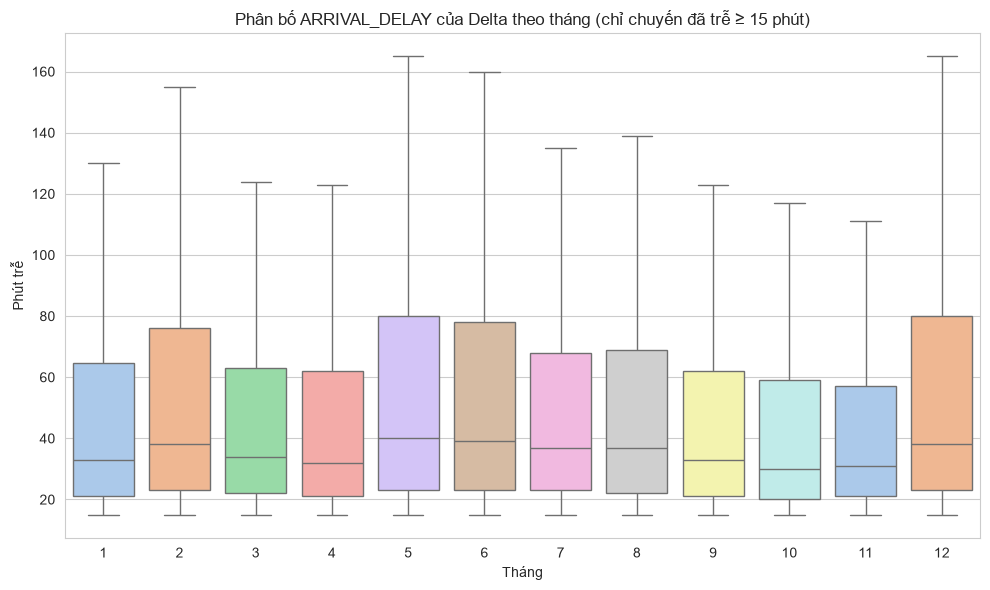

[8b] Median phut tre theo thang (chuyen bi tre), thap den cao:


MONTH
10    30.0
11    31.0
4     32.0
1     33.0
9     33.0
3     34.0
7     37.0
8     37.0
2     38.0
12    38.0
6     39.0
5     40.0
Name: ARRIVAL_DELAY, dtype: float32

In [29]:
delayed = df[df["IS_DELAYED"] == 1]

plt.figure(figsize=(10, 6))
sns.boxplot(data=delayed, x="MONTH", y="ARRIVAL_DELAY", showfliers=False,
            hue="MONTH", palette="pastel", legend=False)
plt.title("Phân bố ARRIVAL_DELAY của Delta theo tháng (chỉ chuyến đã trễ ≥ 15 phút)")
plt.xlabel("Tháng")
plt.ylabel("Phút trễ")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "chart6_boxplot_tre_theo_thang.png"), dpi=150)
plt.show()

median_delay_by_month = delayed.groupby("MONTH")["ARRIVAL_DELAY"].median().sort_values()
print("[8b] Median phut tre theo thang (chuyen bi tre), thap den cao:")
median_delay_by_month

**📌 Nhận xét:** **tháng 5 có median phút trễ cao nhất (40 phút)**, dù đây **không phải** tháng có tần suất trễ cao nhất (đó là tháng 2, với chỉ 80,4% đúng giờ). Ngược lại, **tháng 10 thấp nhất cả về tần suất lẫn mức độ nghiêm trọng** (median 30 phút) — xác nhận đây là tháng vận hành tốt nhất trong năm của Delta trên cả hai khía cạnh. Điều này cho thấy **tần suất trễ và mức độ nghiêm trọng của trễ là hai khía cạnh độc lập**, cần được theo dõi riêng biệt khi lập kế hoạch nguồn lực dự phòng — một tháng có thể ít trễ nhưng khi đã trễ thì trễ rất nặng (như tháng 5), hoặc ngược lại.

### Tổng kết Phân tích Chẩn đoán

Nguyên nhân trễ hàng đầu của Delta nằm ở **nội bộ hãng** (37,4%) chứ không phải yếu tố khách quan như thời tiết — khác với xu hướng chung của toàn ngành. Rủi ro trễ **tăng dần trong ngày và đạt đỉnh lúc 18h**, với bằng chứng tương quan ủng hộ giả thuyết trễ dây chuyền, đặc biệt nghiêm trọng hơn vào Thứ Năm. Về mức độ nghiêm trọng, **tháng 5 là tháng đáng lo nhất** dù không phải tháng trễ thường xuyên nhất — cho thấy cần phân biệt rõ giữa "trễ nhiều lần" và "trễ nặng" khi ra quyết định.

## 5. Tổng hợp phát hiện chính (Key Findings)

In [30]:
worst_month_row = monthly.loc[monthly["ON_TIME_RATE"].idxmin()]
best_month_row = monthly.loc[monthly["ON_TIME_RATE"].idxmax()]
worst_airport = airport_rate.index[0]
worst_route = route_delay.index[0] if len(route_delay) else "N/A"
worst_route_rate = route_delay.iloc[0] if len(route_delay) else float("nan")
worst_route_n = int(top_routes_risk["total_flights"].iloc[0]) if len(top_routes_risk) else 0
main_reason = reason_pct.idxmax()
worst_hour_row = hour_summary.loc[hour_summary["delay_rate"].idxmax()]
worst_hour = int(worst_hour_row.name)
worst_hour_rate = float(worst_hour_row["delay_rate"])
worst_severity_month = int(median_delay_by_month.index[-1])
worst_severity_value = median_delay_by_month.iloc[-1]

key_findings = pd.DataFrame([
    {"ID": "F1", "Dimension": "Overall", "Finding": "Ty le tre chung toan bo Delta Air Lines",
     "Value": f"{overall_rate:.1f}%"},
    {"ID": "F2", "Dimension": "Season", "Finding": f"Thang co ty le dung gio thap nhat: thang {int(worst_month_row['MONTH'])}",
     "Value": f"{worst_month_row['ON_TIME_RATE']:.1f}% dung gio"},
    {"ID": "F3", "Dimension": "Season", "Finding": f"Thang co ty le dung gio cao nhat: thang {int(best_month_row['MONTH'])}",
     "Value": f"{best_month_row['ON_TIME_RATE']:.1f}% dung gio"},
    {"ID": "F4", "Dimension": "Airport", "Finding": f"San bay khoi hanh co ty le tre cao nhat: {worst_airport}",
     "Value": f"{airport_rate.max():.1f}% (cao hon TB {airport_rate.max()-overall_rate:.1f} diem %)"},
    {"ID": "F5", "Dimension": "Route", "Finding": f"Tuyen rui ro cao nhat (>= {MIN_FLIGHTS} chuyen): {worst_route}",
     "Value": f"{worst_route_rate:.1f}% tren {worst_route_n:,} chuyen"},
    {"ID": "F6", "Dimension": "Cause", "Finding": f"Nguyen nhan tre chiem ty trong lon nhat: {main_reason}",
     "Value": f"{reason_pct.max():.1f}% tong phut tre"},
    {"ID": "F7", "Dimension": "Time", "Finding": f"Khung gio co ty le tre cao nhat: {worst_hour}h",
     "Value": f"{worst_hour_rate:.1f}%"},
    {"ID": "F8", "Dimension": "Severity", "Finding": f"Thang co muc do tre nghiem trong nhat (median phut tre): thang {worst_severity_month}",
     "Value": f"{worst_severity_value:.0f} phut"},
])

key_findings.to_csv(os.path.join(BASE_DIR, "key_findings.csv"), index=False)
key_findings

,ID,Dimension,Finding,Value
0,F1,Overall,Ty le tre chung toan bo Delta Air Lines,13.6%
1,F2,Season,Thang co ty le dung gio thap nhat: thang 2,80.4% dung gio
2,F3,Season,Thang co ty le dung gio cao nhat: thang 10,92.2% dung gio
3,F4,Airport,San bay khoi hanh co ty le tre cao nhat: LGA,21.1% (cao hon TB 7.6 diem %)
4,F5,Route,Tuyen rui ro cao nhat (>= 500 chuyen): SFO - LAX,"43.8% tren 1,570 chuyen"
5,F6,Cause,Nguyen nhan tre chiem ty trong lon nhat: Hãng ...,37.4% tong phut tre
6,F7,Time,Khung gio co ty le tre cao nhat: 18h,20.2%
7,F8,Severity,Thang co muc do tre nghiem trong nhat (median ...,40 phut


**Bảng số liệu hỗ trợ phần Chỉ định (Prescriptive Analysis):**

In [31]:
recommendation_evidence = pd.DataFrame([
    {"Finding": "Airport", "Metric": "Delay Rate", "Value": f"{airport_rate.max():.1f}%",
     "Implication": f"San bay {worst_airport} can duoc uu tien ra soat nguyen nhan van hanh"},
    {"Finding": "Peak Hour", "Metric": "Delay Rate", "Value": f"{worst_hour_rate:.1f}%",
     "Implication": f"Nen tang buffer thoi gian / bo tri may bay du phong vao khung {worst_hour}h"},
    {"Finding": "Route", "Metric": "Delay Rate",
     "Value": f"{worst_route_rate:.1f}% tren {worst_route_n:,} chuyen",
     "Implication": f"Uu tien nguon luc du phong cho tuyen {worst_route}"},
    {"Finding": "Cause", "Metric": "Share of Delay Minutes", "Value": f"{reason_pct.max():.1f}%",
     "Implication": "Van de chinh nam o van hanh/xoay vong may bay, can cai thien lich trinh quay dau"},
    {"Finding": "Season", "Metric": "On-time Rate",
     "Value": f"Thang {int(worst_month_row['MONTH'])}: {worst_month_row['ON_TIME_RATE']:.1f}%",
     "Implication": "Can chuan bi nguon luc du phong truoc mua cao diem (he)"},
    {"Finding": "Severity", "Metric": "Median Arrival Delay",
     "Value": f"Thang {worst_severity_month}: {worst_severity_value:.0f} phut",
     "Implication": "Ngoai tan suat, can chu y thang co muc do tre nghiem trong hon khi len ke hoach du phong"},
])
recommendation_evidence.to_csv(os.path.join(BASE_DIR, "recommendation_evidence.csv"), index=False)
recommendation_evidence

,Finding,Metric,Value,Implication
0,Airport,Delay Rate,21.1%,San bay LGA can duoc uu tien ra soat nguyen nh...
1,Peak Hour,Delay Rate,20.2%,Nen tang buffer thoi gian / bo tri may bay du ...
2,Route,Delay Rate,"43.8% tren 1,570 chuyen",Uu tien nguon luc du phong cho tuyen SFO - LAX
3,Cause,Share of Delay Minutes,37.4%,"Van de chinh nam o van hanh/xoay vong may bay,..."
4,Season,On-time Rate,Thang 2: 80.4%,Can chuan bi nguon luc du phong truoc mua cao ...
5,Severity,Median Arrival Delay,Thang 5: 40 phut,"Ngoai tan suat, can chu y thang co muc do tre ..."


In [32]:
airport_summary.to_csv(os.path.join(BASE_DIR, "airport_delay_summary.csv"))
monthly.to_csv(os.path.join(BASE_DIR, "monthly_delay_summary.csv"), index=False)
route_summary_eligible.to_csv(os.path.join(BASE_DIR, "route_delay_summary.csv"))
reason_pct.to_csv(os.path.join(BASE_DIR, "delay_cause_summary.csv"))
median_delay_by_month.to_csv(os.path.join(BASE_DIR, "month_severity_summary.csv"))

print("Da xuat: key_findings.csv, recommendation_evidence.csv, "
      "airport/monthly/route/hour/delay_cause/month_severity_summary.csv")

Da xuat: key_findings.csv, recommendation_evidence.csv, airport/monthly/route/hour/delay_cause/month_severity_summary.csv


## 6. Tóm tắt điều hành (Executive Summary)

| Khía cạnh | Phát hiện chính |
|---|---|
| **Tổng quan** | Tỷ lệ trễ chung của Delta là **13,6%** (118.023/870.275 chuyến) |
| **Mùa vụ** | Tệ nhất **tháng 2** (80,4% đúng giờ), tốt nhất **tháng 10** (92,2%) — chênh 11,8 điểm % |
| **Sân bay** | **LGA** rủi ro cao nhất (21,1%, +7,6 điểm % so với TB) — các sân bay Đông Bắc (LGA, JFK, BOS, ORD) đều nổi bật |
| **Tuyến bay** | **SFO–LAX** rủi ro cao nhất (43,8%/1.570 chuyến) — đặc biệt cả hai chiều SFO↔LAX đều lọt top 2 |
| **Nguyên nhân** | **Hãng hàng không** (37,4%) là nguyên nhân lớn nhất — khác biệt so với xu hướng chung toàn ngành |
| **Thời điểm** | Rủi ro cao nhất lúc **18h** (20,2%); **Thứ Năm** nổi bật, **Thứ Bảy** thấp nhất |
| **Mức độ nghiêm trọng** | **Tháng 5** trễ nặng nhất khi đã trễ (median 40 phút) — khác tháng trễ thường xuyên nhất (tháng 2) |

**Kết luận chung:** nguy cơ trễ chuyến của Delta không phân bố ngẫu nhiên mà tập trung rõ theo 3 chiều — **thời gian** (mùa hè, khung chiều-tối, Thứ Năm), **không gian** (sân bay và tuyến khu vực Đông Bắc, đặc biệt cặp SFO↔LAX), và **nguyên nhân vận hành nội bộ** hơn là yếu tố khách quan như thời tiết. Đây là cơ sở dữ liệu cụ thể để phần Chỉ định (Prescriptive Analysis) đề xuất giải pháp ưu tiên đúng trọng tâm — thay vì các khuyến nghị chung chung — trước khi bước vào mùa cao điểm tiếp theo.